# Functional Density Forecasting (FDF)

In [1]:
import numpy as np 
import pandas as pd
from scipy.stats import norm, t, norminvgauss, levy_stable, genpareto
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt
import plotly.express as px

import sys
sys.path.append("../..")
from src.legacy.preprocessing import align_densities
from src.legacy.kde import verify_density_area 
from src.legacy.transformations import (
                            dens2lqd,
                            lqd2dens,
                            mLQDT,
                            obtain_lqds,
                            obtain_densities_from_lqd,
                            compute_lqd_cut
                            )
import src.legacy.simulations as sim
from src.legacy.plotting import px_select_menu

# Monte Carlo Simulation Design

This section describes the Monte Carlo design used to evaluate the performance of the proposed density forecasting framework.

## Data Generating Process

Let $\{f_t\}_{t=1}^T$ be a sequence of probability density functions defined on a compact support $\mathcal{U} \subset \mathbb{R}$. Each $f_t$ is drawn from a flexible class of distributions, including:

- **Gaussian distribution**
$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

- **Student-$t$ distribution**
$$
f(x) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)} 
\left(1 + \frac{x^2}{\nu}\right)^{-\frac{\nu+1}{2}}
$$

To model densities in a Hilbert space, we apply a transformation $\Lambda_q(\cdot)$:

$$
Y_t(u) = [\Lambda_q(f)(u) + X_{0t}(u)] + \varepsilon_t(u), \quad u \in \mathcal{U}.
$$

where $\varepsilon_t$ is a zero-mean noise process and $[\Lambda_q(f_t)(u) + X_{0t}(u)]$ captures the serial dependence structure.

$$
\Lambda(f)(u) + W_{1t} \sin(2\pi u) + ... + W_{pt} \sin(2p\pi u) + BB_t(u)
$$

---

## Functional Representation

The latent process $X_t$ is expanded in an orthonormal Fourier basis:

$$
X_t(u) = \sum_{k=1}^{d} \eta_{t,k} \, \phi_k(u),
$$

where the basis functions are defined as:

$$
\phi_{2k-1}(u) = \sqrt{2}\cos(\pi k u), \quad
\phi_{2k}(u) = \sqrt{2}\sin(\pi k u), \quad k \geq 1.
$$

The coefficient vector $\boldsymbol{\eta}_t = (\eta_{t,1}, \dots, \eta_{t,d})'$ follows a vector autoregressive process:

$$
\boldsymbol{\eta}_t = A \boldsymbol{\eta}_{t-1} + \boldsymbol{\xi}_t,
$$

where $A$ is a stable coefficient matrix and $\boldsymbol{\xi}_t$ is white noise.

---

## Inverse Transformation and Sampling

The simulated densities are obtained via the inverse transformation:

$$
\tilde{f}_t = \Lambda_q^{-1}(Y_t),
$$

followed by normalization to ensure that $\tilde{f}_t$ integrates to one.

From each density $\tilde{f}_t$, we generate an i.i.d. sample:

$$
\{x_{t,1}, \dots, x_{t,n}\} \sim \tilde{f}_t.
$$

---

## Estimation and Forecasting Procedure

For each Monte Carlo replication:

1. **Density Estimation**  
   Estimate $\hat{f}_t$ using kernel density estimation (KDE) based on $\{x_{t,1}, \dots, x_{t,n}\}$.

2. **Train-Test Split**

$$
\mathcal{T}_0 = \{\hat{f}_1, \dots, \hat{f}_{t_0}\}, \quad
\mathcal{T}_1 = \{\hat{f}_{t_0+1}, \dots, \hat{f}_T\}.
$$

3. **Transformation**

$$
\hat{Y}_t = \Lambda_q(\hat{f}_t)
$$

4. **Functional PCA (FPCA)**  
   Apply FPCA to $\{\hat{Y}_t\}_{t \in \mathcal{T}_0}$ to obtain:
   - Eigenfunctions $\{\hat{\psi}_k\}_{k=1}^d$
   - Scores $\hat{\eta}_{t,k}$

5. **Time Series Modeling**  
   Fit a VAR($p$) model to $\hat{\boldsymbol{\eta}}_t$.

6. **Forecasting and Reconstruction**

$$
\hat{Y}_{t+1}(u) = \sum_{k=1}^{d} \hat{\eta}_{t+1,k} \, \hat{\psi}_k(u)
$$

7. **Inverse Mapping**

$$
\hat{f}_{t+1} = \Lambda_q^{-1}(\hat{Y}_{t+1})
$$

---

## Evaluation

Forecast accuracy is assessed via:

$$
L\big(\hat{f}_{t+1}, f_{t+1}\big),
$$

where $L(\cdot,\cdot)$ may include:

- $L^2$ distance  
- Kullback--Leibler divergence  
- Jensen--Shannon divergence  

---

## Base pdfs

In [2]:
m = 1000
x = np.linspace(-6, 6, m)

pdf_t3     = sim.t_density(x, df=3)
pdf_t5     = sim.t_density(x, df=5)
pdf_normal = sim.normal_density(x)

In [3]:
df = pd.DataFrame({
    "x": x,
    "Student-t (df=3)": pdf_t3,
    "Student-t (df=5)": pdf_t5,
    "Normal": pdf_normal
})

fig = px.line(
    df, 
    x="x", 
    y=[col for col in df.columns if col != "x"],
    title="Base densities",
    labels={"value": "Density", "variable": "Distribution", "x": "Returns"},
    template="plotly_dark"
)

fig.update_traces(line=dict(width=2))

fig.update_layout(
    legend_title_text='Model Type',
    yaxis=dict(title="Probability Density")
)

px_select_menu(fig)
fig.show()

## Transformations

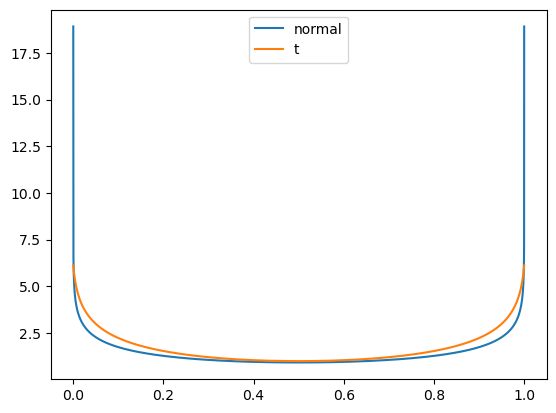

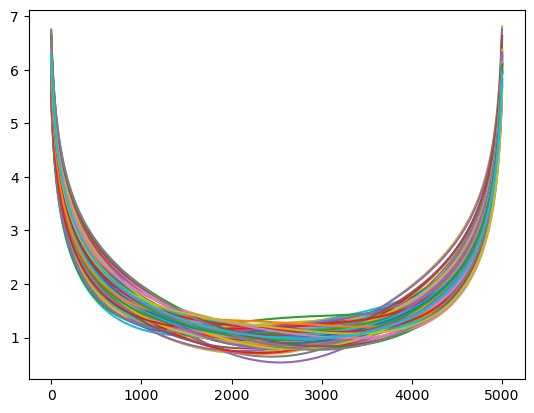

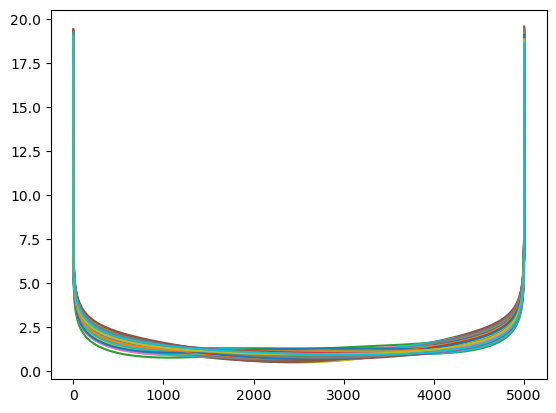

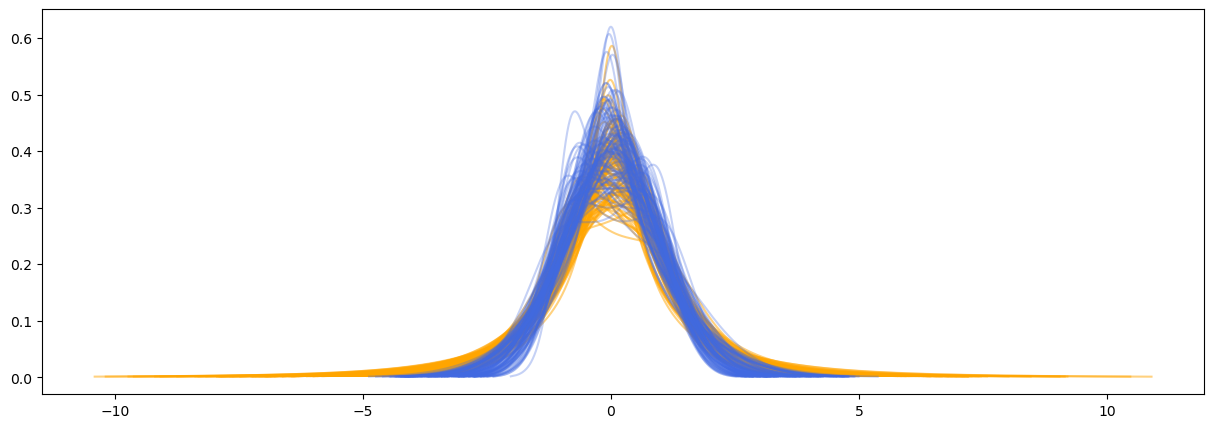

In [5]:
lqd_support = np.linspace(0,1,5001)
t0_ = x[np.argmin(np.abs(x))]
lqdsup, lqd_t, c = dens2lqd(
                        dens = pdf_t3, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = t0_,
                        verbose=True
                        )
lqdsup, lqd_n, c = dens2lqd(
                        dens = pdf_normal, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = t0_,
                        verbose=True
                        )
plt.figure()

plt.plot(lqdsup, lqd_n, label="normal")
plt.plot(lqdsup, lqd_t, label="t")

plt.legend()
plt.show()
# lqd_t = lqd
phis = [0.8, -0.5] # Strong persistence in shape 1, oscillating shape 2
curves, _ = sim.simulate_dependent_densities(100, lqd_t, phis)
df_lqds_t = pd.DataFrame(curves)
df_lqds_t.plot(legend=False)
phis = [0.8, -0.5] # Strong persistence in shape 1, oscillating shape 2
curves, _ = sim.simulate_dependent_densities(100, lqd_n, phis)
df_lqds_n = pd.DataFrame(curves)
df_lqds_n.plot(legend=False)
bkw_supports_t, bkw_densities_t = obtain_densities_from_lqd(
                                                            df_lqds_t,
                                                            lqd_support,
                                                            c_=[c for i in range(df_lqds_t.shape[1])],
                                                            t_=[0 for i in range(df_lqds_t.shape[1])],
                                                            verbose=False
                                                            )

bkw_supports_n, bkw_densities_n = obtain_densities_from_lqd(
                                                            df_lqds_n,
                                                            lqd_support,
                                                            c_=[c for i in range(df_lqds_t.shape[1])],
                                                            t_=[0 for i in range(df_lqds_t.shape[1])],
                                                            verbose=False
                                                            )
plt.figure(figsize=(15,5))
for i in range(bkw_densities_t.shape[1]):
    plt.plot(bkw_supports_t.iloc[:,i], bkw_densities_t.iloc[:,i], c="orange", label= "t-student", alpha=.5)

for i in range(bkw_densities_n.shape[1]):
    plt.plot(bkw_supports_n.iloc[:,i], bkw_densities_n.iloc[:,i], c="royalblue", label="normal", alpha=.3)
plt.show()

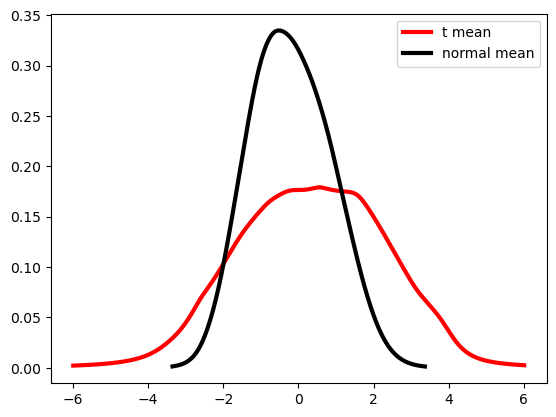

In [5]:
# Mean comparison
plt.plot(
    bkw_supports_t.iloc[:,0],
    bkw_densities_t.mean(axis=1),
    c="red",
    lw=3,
    label="t mean"
)

plt.plot(
    bkw_supports_n.iloc[:,0],
    bkw_densities_n.mean(axis=1),
    c="black",
    lw=3,
    label="normal mean"
)

plt.legend()

plt.show()

## Sampling from KDE

[]

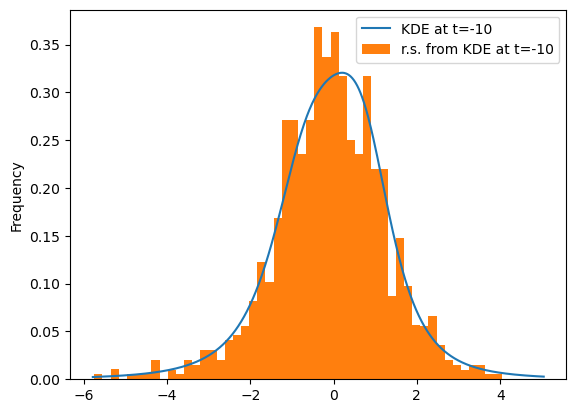

In [11]:
t=-10

returns_day_1 = sim.sample_from_density(bkw_supports_t.iloc[:, t], bkw_densities_t.iloc[:, t])
plt.plot(bkw_supports_t.iloc[:, t], bkw_densities_t.iloc[:, t], label=f"KDE at t={t}")
pd.Series(returns_day_1).plot(kind="hist", bins=50,density=True, label=f"r.s. from KDE at t={t}")

plt.legend()

plt.plot()

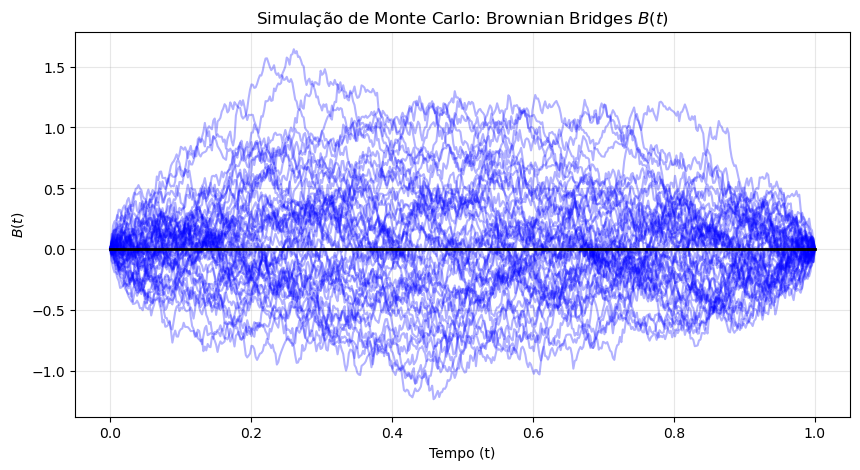

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_brownian_bridges(n_paths=5, n_steps=1000, seed=None):
    """
    Simula múltiplos caminhos de uma Brownian Bridge no intervalo [0, 1].
    
    A fórmula utilizada é: B(t) = W(t) - t * W(1)
    Onde W(t) é um Movimento Browniano padrão.
    """
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, n_steps)
    dt = 1.0 / (n_steps - 1)
    
    # 1. Gerar incrementos do Movimento Browniano: dW ~ N(0, sqrt(dt))
    dW = rng.normal(0, np.sqrt(dt), size=(n_paths, n_steps))
    dW[:, 0] = 0  # Início em zero
    
    # 2. Movimento Browniano padrão (Soma acumulada dos incrementos)
    W = np.cumsum(dW, axis=1)
    
    # 3. Transformação para Brownian Bridge: B(t) = W(t) - t * W(1)
    # W[:, -1] é o valor final W(1) para cada caminho
    W_1 = W[:, -1][:, np.newaxis]
    B = W - t * W_1
    
    return t, B

# --- Exemplo de Uso ---
t, bridges = simulate_brownian_bridges(n_paths=50, n_steps=500, seed=42)

plt.figure(figsize=(10, 5))
plt.plot(t, bridges.T, alpha=0.3, color='blue')
plt.plot(t, np.zeros_like(t), color='black', lw=2) # Linha de base
plt.title("Simulação de Monte Carlo: Brownian Bridges $B(t)$")
plt.xlabel("Tempo (t)")
plt.ylabel("$B(t)$")
plt.grid(True, alpha=0.3)
plt.show()

[]

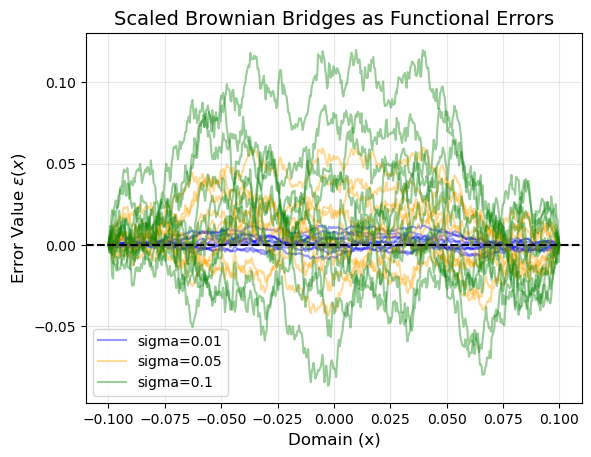

In [5]:
import numpy as np

def generate_functional_error(x_grid, sigma=0.1, n_paths=1, seed=None):
    """
    Generates a Brownian Bridge scaled to a specific spatial grid and magnitude.
    
    Args:
        x_grid (np.ndarray): The support of your functional data (e.g., np.linspace(-5, 5, 100)).
        sigma (float): Scaling factor for the error magnitude.
        n_paths (int): Number of error functions to generate.
    """
    rng = np.random.default_rng(seed)
    n_steps = len(x_grid)
    
    # 1. Standardize the grid to [0, 1] for the bridge calculation
    t = (x_grid - x_grid[0]) / (x_grid[-1] - x_grid[0])
    dt = 1.0 / (n_steps - 1)
    
    # 2. Generate standard Brownian Motion
    dW = rng.normal(0, np.sqrt(dt), size=(n_paths, n_steps))
    dW[:, 0] = 0
    W = np.cumsum(dW, axis=1)
    
    # 3. Create Bridge: B(t) = W(t) - t * W(1)
    W_1 = W[:, -1][:, np.newaxis]
    bridge = W - t * W_1
    
    # 4. Scale by sigma
    # Note: Multiplying by sigma scales the standard deviation.
    return bridge * sigma

# Generate data for plotting
x = np.linspace(-0.1, 0.1, 500)
n_paths = 10
sigmas = [0.01, 0.05, 0.1]
colors = ['blue', 'orange', 'green']

plt.clf()
for s, c in zip(sigmas, colors):
    errors = generate_functional_error(x, sigma=s, n_paths=n_paths, seed=42)
    for i in range(n_paths):
        label = f'sigma={s}' if i == 0 else None
        plt.plot(x, errors[i], color=c, alpha=0.4, label=label)

plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.title("Scaled Brownian Bridges as Functional Errors", fontsize=14)
plt.xlabel("Domain (x)", fontsize=12)
plt.ylabel("Error Value $\epsilon(x)$", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.plot()

# Synthetic 'noisy' functional observation
# noisy_density = true_density + error